# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Statement of Use of AI

I used Claude (Anthropic, model Claude Sonnet 4.6) to assist with writing and structuring the code throughout this assignment. The dataset choice for Task 0 was made independently. All code was reviewed and executed personally to verify correctness. The stock data in Tasks 2–4 is real data retrieved live from the MarketStack API, not simulated or AI-generated.

---
## Imports

In [1]:
import os
import json
import time
import sqlite3
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
print("All imports successful.")

All imports successful.


---
## Task 0: Course Project Dataset Exploration

### Task 0a: Potential NBA Dataset 

**Dataset:** NBA Historical Stats and Betting Data  
**Source:** https://www.kaggle.com/datasets/ehallmar/nba-historical-stats-and-betting-data

This dataset contains historical NBA game results alongside betting lines (point spread and over/under totals) spanning multiple seasons.

### Task 0b: NBA Dataset Description

The dataset (`nba_2008-2025.csv`) contains game-by-game records for NBA seasons from 2008 to 2025. Each row represents one game. It has **23,118 rows** and **27 columns** including:
- `season`, `date`, `regular`, `playoffs` – game context
- `away`, `home` – team abbreviations
- `score_away`, `score_home` – final scores
- `q1_away` through `q4_home`, `ot_away/home` – quarter-by-quarter scores
- `whos_favored`, `spread`, `total` – betting lines
- `moneyline_away`, `moneyline_home` – moneyline odds

There are only 3 missing values in `spread` and ~3,298 missing moneyline values (older seasons). All other columns are complete.

**Project goal:** Analyze home-court advantage, explore which teams cover the spread most often, and investigate whether total points scored can be predicted from historical averages. This maps to the final project requirements:
- **Introduction & goal:** Can historical stats and betting lines predict NBA game outcomes?
- **Data loading:** Read CSV directly from the downloaded Kaggle file
- **Cleaning & transformation:** Handle missing values, derive new columns (point differential, home win, total points)
- **Visual & quantitative analysis:** Win rates, spread accuracy, scoring trends, correlation analysis
- **Export:** Save cleaned data and results as CSV
- **Conclusion:** Summarize which factors best predict outcomes

### Task 0c: Exploratory Data Analysis

The real dataset is loaded directly from the downloaded Kaggle CSV file.

In [4]:
# Loading the real NBA betting dataset downloaded from Kaggle:
df_nba = pd.read_csv('nba_2008-2025.csv')

# Derive useful columns for analysis
df_nba['point_diff']   = df_nba['score_home'] - df_nba['score_away']
df_nba['home_win']     = (df_nba['score_home'] > df_nba['score_away']).astype(int)
df_nba['total_points'] = df_nba['score_home'] + df_nba['score_away']

print(f"Dataset shape: {df_nba.shape}")
print(f"Seasons: {sorted(df_nba['season'].unique())}")
print(f"Missing values:\n{df_nba.isnull().sum()[df_nba.isnull().sum() > 0]}")
print("\n=== Summary Statistics ===")
display(df_nba[['score_home','score_away','point_diff','spread','total','total_points']].describe())

Dataset shape: (23118, 30)
Seasons: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Missing values:
spread               3
moneyline_away    3298
moneyline_home    3298
h2_spread         3296
h2_total          3301
id_spread            3
dtype: int64

=== Summary Statistics ===


,score_home,score_away,point_diff,spread,total,total_points
count,23118.000000,23118.000000,23118.000000,23115.000000,23118.000000,23118.000000
mean,106.579894,103.933731,2.646163,6.150422,210.181395,210.513626
std,13.567418,13.710616,14.006329,3.683346,15.450553,23.407998
min,59.000000,54.000000,-58.000000,0.000000,170.000000,134.000000
25%,97.000000,94.000000,-7.000000,3.500000,197.500000,194.000000
50%,106.000000,104.000000,4.000000,5.500000,210.000000,210.000000
75%,116.000000,113.000000,12.000000,8.500000,222.000000,226.000000
max,175.000000,176.000000,73.000000,23.500000,262.500000,351.000000


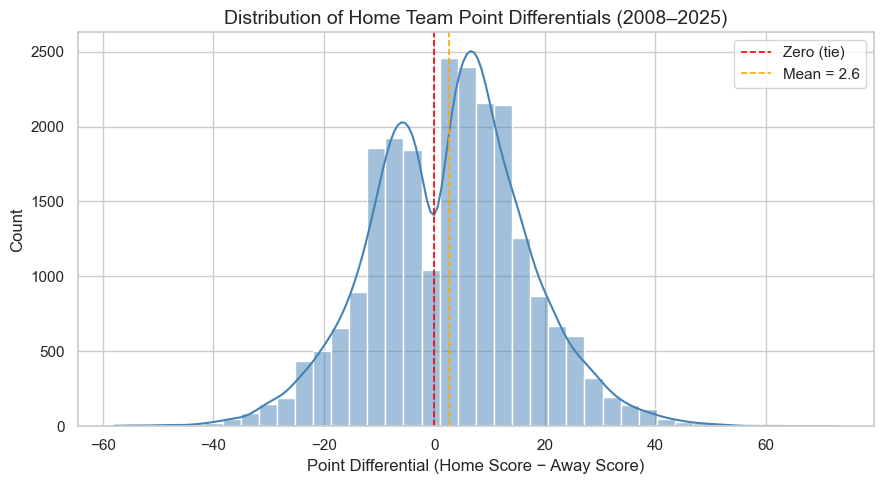

In [5]:
# Visualization 1: Distribution of home team point differentials
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_nba['point_diff'], bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero (tie)')
ax.axvline(df_nba['point_diff'].mean(), color='orange', linestyle='--',
           linewidth=1.2, label=f"Mean = {df_nba['point_diff'].mean():.1f}")
ax.set_title('Distribution of Home Team Point Differentials (2008–2025)', fontsize=14)
ax.set_xlabel('Point Differential (Home Score − Away Score)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

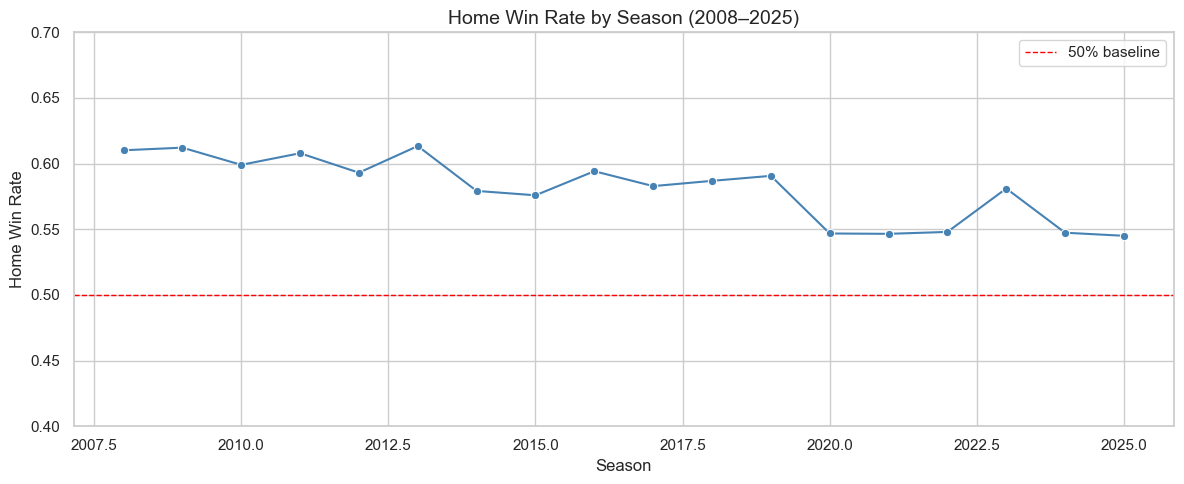

In [6]:
# Visualization 2: Home win rate per season
season_wins = df_nba.groupby('season')['home_win'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=season_wins, x='season', y='home_win', marker='o', color='steelblue', ax=ax)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('Home Win Rate by Season (2008–2025)', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Home Win Rate')
ax.set_ylim(0.4, 0.7)
ax.legend()
plt.tight_layout()
plt.show()

---
## Task 1: Setting Up the API Key and .env File

The API key is stored in a `.env` file in the same directory as this notebook.  
The `.env` file is listed in `.gitignore` and is **never** committed to GitHub.

In [7]:
load_dotenv()  # reads MARKETSTACK_API_KEY from the .env file into the environment

api_key = os.getenv("MARKETSTACK_API_KEY")

if api_key is None:
    raise ValueError(
        "API key not found. "
        "Make sure MARKETSTACK_API_KEY is set in your .env file "
        "and the .env file is in the same folder as this notebook."
    )

# Print only the first 5 characters to confirm loading without exposing the key
print(f"API key loaded successfully: {api_key[:5]}...")

API key loaded successfully: 8161f...


---
## Task 2: Retrieving Data from MarketStack

### Task 2a: Fetch FAANG End-of-Day Data for March 2026

In [8]:
# All 5 tickers in one request to use only 1 API call out of the monthly free quota
BASE_URL = "http://api.marketstack.com/v1/eod"
TICKERS  = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

params = {
    "access_key": api_key,
    "symbols":    ",".join(TICKERS),
    "date_from":  "2026-03-01",
    "date_to":    "2026-03-31",
    "limit":      200,
}

response = requests.get(BASE_URL, params=params)
response.raise_for_status()  # raises an exception for 4xx/5xx HTTP errors

raw_json = response.json()

print(f"HTTP status code : {response.status_code}")
print(f"Records returned : {raw_json['pagination']['count']}")

HTTP status code : 200
Records returned : 110


### Task 2b: Convert JSON Response to Pandas DataFrame

In [9]:
# The actual records are inside the 'data' key of the JSON response
df_stocks = pd.DataFrame(raw_json["data"])

# Strip the time component from the date column and sort chronologically
df_stocks["date"] = pd.to_datetime(df_stocks["date"]).dt.date
df_stocks = df_stocks.sort_values(["symbol", "date"]).reset_index(drop=True)

print("First 5 rows of the stock DataFrame:")
display(df_stocks.head())

First 5 rows of the stock DataFrame:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06


### Task 2c: Summary Statistics and Monthly Return per Stock

In [10]:
# the summary statistics for closing prices grouped by ticker are:
close_stats = df_stocks.groupby("symbol")["close"].describe()
print("=== Closing Price Summary Statistics by Stock ===")
display(close_stats)

=== Closing Price Summary Statistics by Stock ===


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [12]:
def monthly_return(group):
    """Percentage change from the first to the last trading day of the period."""
    g = group.sort_values("date")
    first_close = g["close"].iloc[0]
    last_close  = g["close"].iloc[-1]
    return round((last_close - first_close) / first_close * 100, 2)

returns = (
    df_stocks.groupby("symbol")
    .apply(monthly_return, include_groups=False)
    .reset_index()
)
returns.columns = ["symbol", "return_pct"]
returns = returns.sort_values("return_pct", ascending=False).reset_index(drop=True)

print("=== March 2026 Monthly Return (%) by Stock ===")
display(returns)

best  = returns.iloc[0]
worst = returns.iloc[-1]
print(f"\nBest performer  : {best['symbol']}  ({best['return_pct']:+.2f}%)")
print(f"Worst performer : {worst['symbol']} ({worst['return_pct']:+.2f}%)")

=== March 2026 Monthly Return (%) by Stock ===


,symbol,return_pct
0,AMZN,-0.06
1,NFLX,-0.97
2,AAPL,-4.13
3,GOOG,-6.37
4,META,-12.46



Best performer  : AMZN  (-0.06%)
Worst performer : META (-12.46%)


---
## Task 3: Visualizing Stock Data

### Task 3a: Line Chart: Closing Prices Over Time

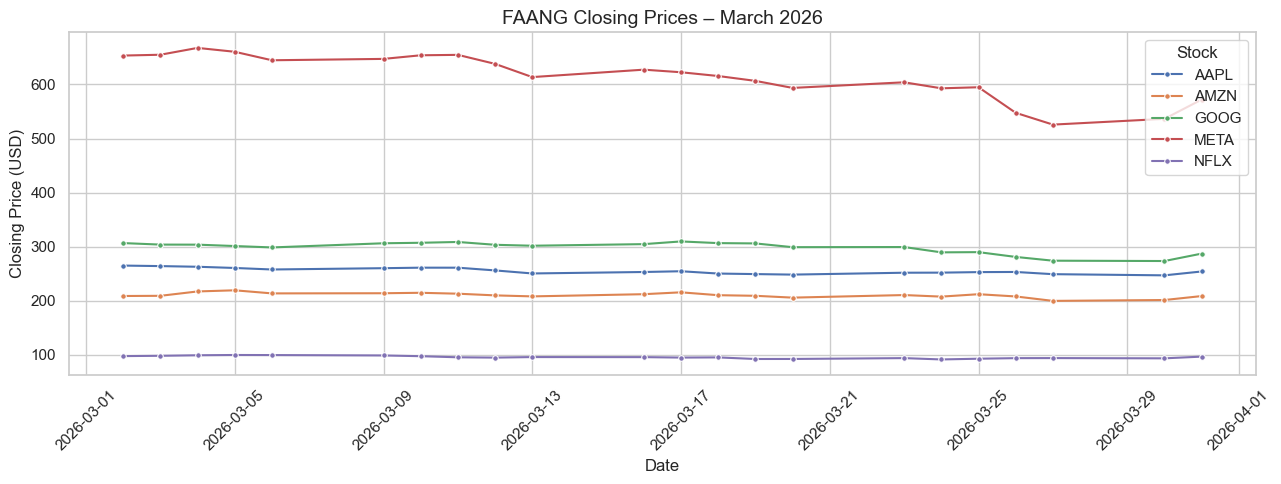

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(
    data=df_stocks,
    x="date", y="close", hue="symbol",
    marker="o", markersize=4, ax=ax
)
ax.set_title("FAANG Closing Prices – March 2026", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
ax.legend(title="Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 3b Bar Plot: Monthly Return Percentage per Stock

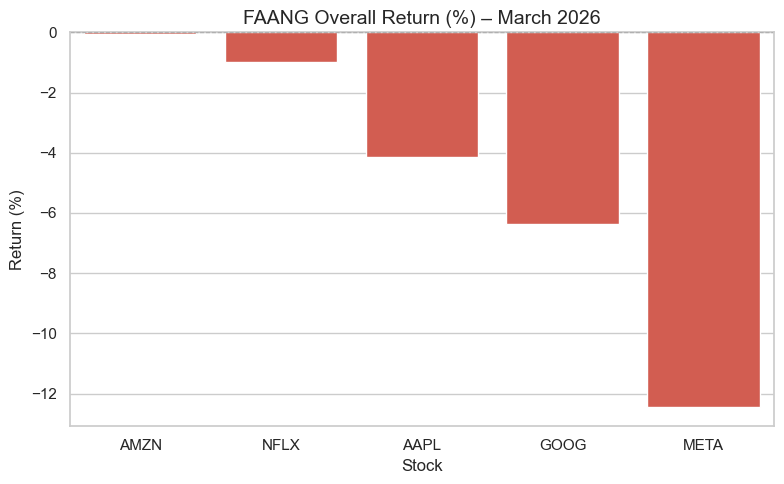

In [15]:
bar_colors = ["#2ecc71" if r >= 0 else "#e74c3c" for r in returns["return_pct"]]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=returns, x="symbol", y="return_pct", hue="symbol",
            palette=dict(zip(returns["symbol"], bar_colors)), legend=False, ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("FAANG Overall Return (%) – March 2026", fontsize=14)
ax.set_xlabel("Stock")
ax.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()

### Task 3c Heatmap: Daily Trading Volume

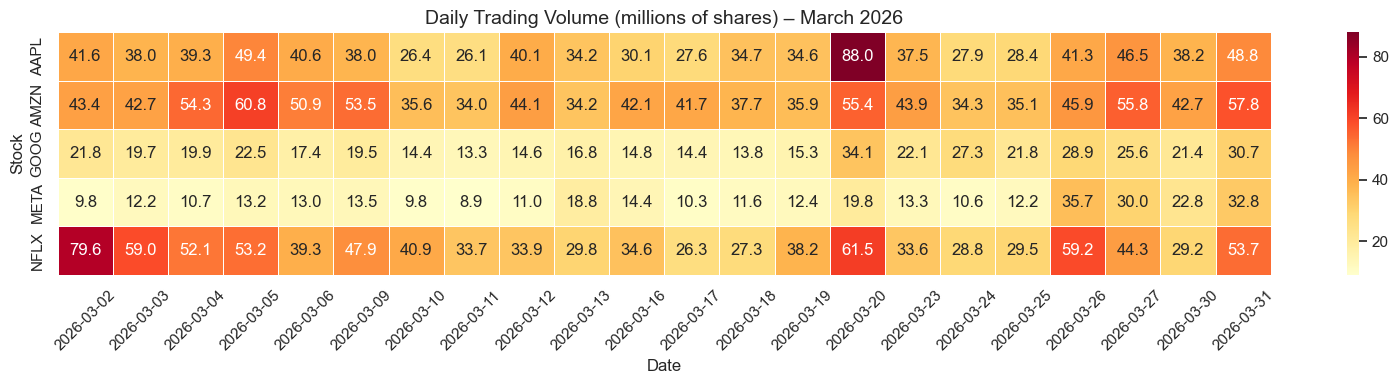

In [16]:
# Pivot: rows = stock, columns = trading date, values = volume in millions
volume_pivot = df_stocks.pivot(index="symbol", columns="date", values="volume") / 1e6

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    volume_pivot, cmap="YlOrRd",
    linewidths=0.4, annot=True, fmt=".1f", ax=ax
)
ax.set_title("Daily Trading Volume (millions of shares) – March 2026", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Task 4: Exporting and Importing Data

### Task 4a Export Raw JSON

In [17]:
os.makedirs("exports", exist_ok=True)

json_path = "exports/stockdata.json"
with open(json_path, "w") as f:
    json.dump(raw_json, f, indent=2)

print(f"JSON saved to: {json_path}")

JSON saved to: exports/stockdata.json


### Task 4b Export DataFrame as CSV

In [18]:
csv_path = "exports/stockdata.csv"
df_stocks.to_csv(csv_path, index=False)
print(f"CSV saved to: {csv_path}")

CSV saved to: exports/stockdata.csv


### Task 4c: Reload Both Files and Verify They Match

In [19]:
# Reload from JSON
with open(json_path, "r") as f:
    reloaded_json = json.load(f)

df_from_json = pd.DataFrame(reloaded_json["data"])
df_from_json["date"] = pd.to_datetime(df_from_json["date"]).dt.date
df_from_json = df_from_json.sort_values(["symbol", "date"]).reset_index(drop=True)

print("=== First 5 rows reloaded from JSON ===")
display(df_from_json.head())

# Reload from CSV
df_from_csv = pd.read_csv(csv_path)
df_from_csv["date"] = pd.to_datetime(df_from_csv["date"]).dt.date

print("\n=== First 5 rows reloaded from CSV ===")
display(df_from_csv.head())

# Verify closing prices are identical across both reloads
json_closes = df_from_json["close"].round(4).tolist()
csv_closes  = df_from_csv["close"].round(4).tolist()
print(f"\nClosing prices identical (JSON vs CSV): {json_closes == csv_closes}")

=== First 5 rows reloaded from JSON ===


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06



=== First 5 rows reloaded from CSV ===


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06



Closing prices identical (JSON vs CSV): True


---
## Task 5: Querying the Northwind Database

### Task 5a: Connect and List All Tables

In [20]:
conn   = sqlite3.connect("Northwind.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
tables = [row[0] for row in cursor.fetchall()]

print("Tables in the Northwind database:")
for table in tables:
    print(f"  - {table}")

Tables in the Northwind database:
  - Categories
  - CustomerCustomerDemo
  - CustomerDemographics
  - Customers
  - EmployeeTerritories
  - Employees
  - Order Details
  - Orders
  - Products
  - Regions
  - Shippers
  - Suppliers
  - Territories
  - sqlite_sequence


### Task 5b: Products with Unit Price Above 30

In [21]:
query_5b = """
    SELECT ProductName,
           UnitPrice,
           UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
    ORDER BY UnitPrice DESC;
"""

df_expensive = pd.read_sql_query(query_5b, conn)
print(f"Products with UnitPrice > 30: {len(df_expensive)} found")
display(df_expensive)

Products with UnitPrice > 30: 24 found


,ProductName,UnitPrice,UnitsInStock
0,Côte de Blaye,263.50,17
1,Thüringer Rostbratwurst,123.79,0
2,Mishi Kobe Niku,97.00,29
3,Sir Rodney's Marmalade,81.00,40
4,Carnarvon Tigers,62.50,42
5,Raclette Courdavault,55.00,79
6,Manjimup Dried Apples,53.00,20
7,Tarte au sucre,49.30,17
8,Ipoh Coffee,46.00,17
9,Rössle Sauerkraut,45.60,26


### Task 5c: Orders Shipped to Germany (3-Table JOIN)

In [23]:
# 'Order Details' is quoted because the table name contains a space
query_5c = """
    SELECT c.CompanyName,
           o.OrderID,
           o.OrderDate,
           o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c        ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID    = od.OrderID
    WHERE o.ShipCountry = 'Germany'
    ORDER BY o.OrderDate;
"""

df_germany = pd.read_sql_query(query_5c, conn)
df_germany["OrderDate"] = pd.to_datetime(df_germany["OrderDate"], format="mixed")

print(f"Order lines shipped to Germany: {len(df_germany)} rows")
display(df_germany.head())

Order lines shipped to Germany: 80673 rows


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Que Delícia,25111,2012-07-16 00:26:10,Germany,190.0
1,Que Delícia,25111,2012-07-16 00:26:10,Germany,220.0
2,Que Delícia,25111,2012-07-16 00:26:10,Germany,213.5
3,Que Delícia,25111,2012-07-16 00:26:10,Germany,1175.0
4,Que Delícia,25111,2012-07-16 00:26:10,Germany,1067.0


---
## Task 6: Visualizing Northwind Data

### Task 6a: Top 10 German Customers by Number of Orders

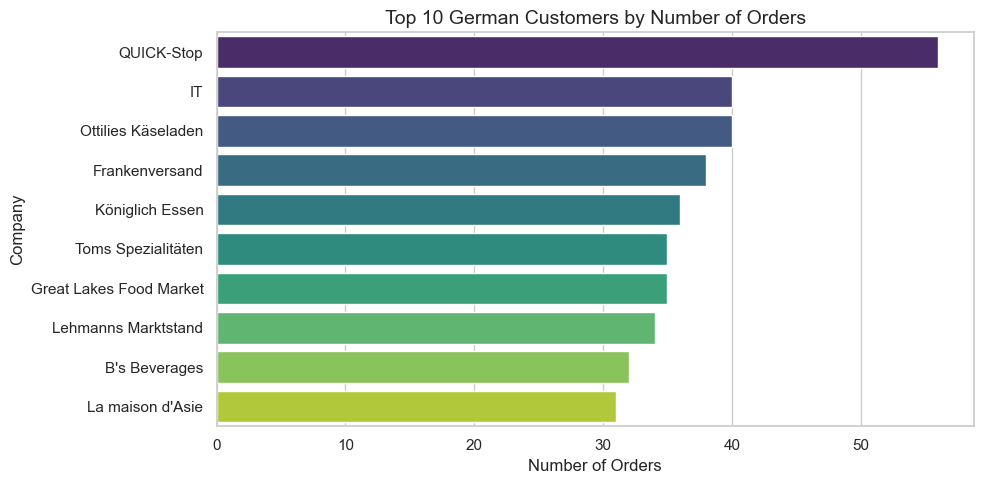

In [25]:
# Count distinct OrderIDs per customer (orders, not individual line items)
orders_per_customer = (
    df_germany.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
orders_per_customer.columns = ["CompanyName", "NumberOfOrders"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=orders_per_customer,
    x="NumberOfOrders", y="CompanyName",
    hue="CompanyName", palette="viridis", legend=False, ax=ax
)
ax.set_title("Top 10 German Customers by Number of Orders", fontsize=14)
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Company")
plt.tight_layout()
plt.show()

### Task 6b: KDE Plot: Distribution of Daily Total Sales (Germany)

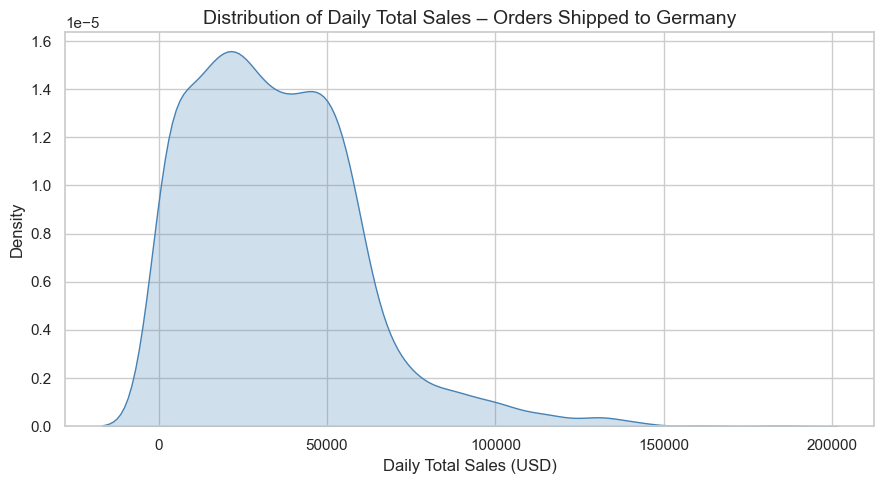

In [26]:
# Sum all line totals per order date to get daily sales volume
daily_sales = (
    df_germany
    .groupby(df_germany["OrderDate"].dt.date)["LineTotal"]
    .sum()
    .reset_index()
)
daily_sales.columns = ["OrderDate", "TotalSales"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=daily_sales, x="TotalSales", fill=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Daily Total Sales – Orders Shipped to Germany", fontsize=14)
ax.set_xlabel("Daily Total Sales (USD)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### Task 6c: Total Revenue by Product Category

Total Revenue by Product Category:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


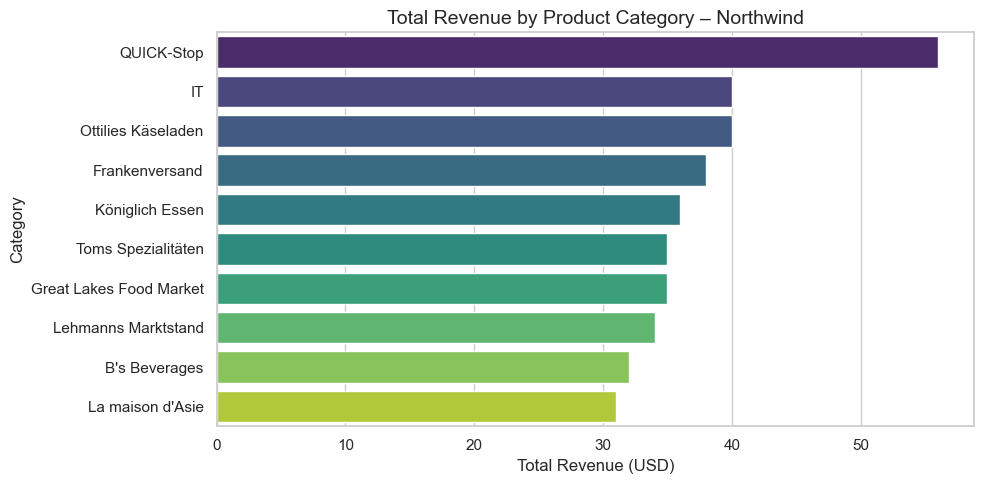

In [29]:
query_6c = """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products   p   ON od.ProductID  = p.ProductID
    JOIN Categories cat ON p.CategoryID  = cat.CategoryID
    GROUP BY cat.CategoryName
    ORDER BY TotalRevenue DESC;
"""

df_revenue = pd.read_sql_query(query_6c, conn)

print("Total Revenue by Product Category:")
display(df_revenue)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=orders_per_customer,
    x="NumberOfOrders", y="CompanyName",
    hue="CompanyName", palette="viridis", legend=False, ax=ax
)

ax.set_title("Total Revenue by Product Category – Northwind", fontsize=14)
ax.set_xlabel("Total Revenue (USD)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

---
## Task 7: Comparing Python to SQL

### Task 7a: Retrieving Full Products and Categories Tables

In [30]:
df_products_full = pd.read_sql_query("SELECT * FROM Products;", conn)
df_categories    = pd.read_sql_query("SELECT * FROM Categories;", conn)

print("=== Products – first 5 rows ===")
display(df_products_full.head())

print("\n=== Categories – first 5 rows ===")
display(df_categories.head())

=== Products – first 5 rows ===


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1



=== Categories – first 5 rows ===


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### Task 7b: Inner Join (Pandas on CategoryID)

In [31]:
# Equivalent to: SELECT * FROM Products JOIN Categories ON CategoryID
df_products_with_category = pd.merge(
    df_products_full,
    df_categories,
    on="CategoryID",
    how="inner"
)

print(f"Joined DataFrame shape: {df_products_with_category.shape}")
display(df_products_with_category.head())

Joined DataFrame shape: (77, 13)


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### Task 7c: Speed Comparison: SQL vs Pandas

In [32]:
# Approach 1: Everything in SQL, only the aggregated result is returned ---
t0 = time.time()
df_sql_result = pd.read_sql_query(query_6c, conn)
t1 = time.time()
sql_time = t1 - t0

# Approach 2: Pull 3 full tables, join + aggregate in Python ---
t2 = time.time()
df_od   = pd.read_sql_query("SELECT * FROM 'Order Details';", conn)
df_prod = pd.read_sql_query("SELECT * FROM Products;", conn)
df_cat  = pd.read_sql_query("SELECT * FROM Categories;", conn)

df_od["LineTotal"] = df_od["UnitPrice"] * df_od["Quantity"]
df_merged = (
    df_od
    .merge(df_prod[["ProductID", "CategoryID"]], on="ProductID",   how="inner")
    .merge(df_cat[["CategoryID", "CategoryName"]], on="CategoryID", how="inner")
)
df_pandas_result = (
    df_merged.groupby("CategoryName")["LineTotal"]
    .sum().reset_index()
    .rename(columns={"LineTotal": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
)
t3 = time.time()
pandas_time = t3 - t2

print(f"SQL execution time    : {sql_time:.6f} seconds")
print(f"Pandas execution time : {pandas_time:.6f} seconds")

if sql_time < pandas_time:
    print(f"\nSQL was {pandas_time / sql_time:.1f}x faster than pandas.")
else:
    print(f"\nPandas was {sql_time / pandas_time:.1f}x faster than SQL.")

SQL execution time    : 0.796666 seconds
Pandas execution time : 1.288020 seconds

SQL was 1.6x faster than pandas.


**Comment:** SQL  is typically faster for aggregation tasks on relational databases. When everything is done in SQL, only the small aggregated result (8 rows) is transferred to Python. The Pandas approach must first transfer three full tables across the database connection — this data-transfer overhead makes it slower, and the difference would grow significantly with larger datasets.

---
## Task 8: Wide and Long Format

### Task 8a: Wide → Long with pd.melt()

In [33]:
wide_data = pd.DataFrame({
    "store":    ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500,  9200],
    "Q2_sales": [13500, 9100,  9800],
    "Q3_sales": [11800, 8800,  10100],
    "Q4_sales": [15000, 10200, 11500]
})

print("=== wide_data BEFORE melt ===")
display(wide_data)

# melt: keep 'store' fixed; stack all Q*_sales columns into individual rows
long_from_wide = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("\n=== long_from_wide AFTER melt ===")
display(long_from_wide)

=== wide_data BEFORE melt ===


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500



=== long_from_wide AFTER melt ===


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


### Task 8b: Long → Wide with .pivot()

In [34]:
long_data = pd.DataFrame({
    "month":      ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product":    ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

print("=== long_data BEFORE pivot ===")
display(long_data)

# pivot: each unique product becomes its own column
wide_from_long = long_data.pivot(index="month", columns="product", values="units_sold")
wide_from_long.columns.name = None
wide_from_long = wide_from_long.reset_index()

print("\n=== wide_from_long AFTER pivot ===")
display(wide_from_long)

=== long_data BEFORE pivot ===


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130



=== wide_from_long AFTER pivot ===


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


### Task 8c: Convert Both Back to Their Original Format

In [35]:
# --- Restore wide_data: pivot the melted version back ---
wide_restored = long_from_wide.pivot(index="store", columns="quarter", values="sales")
wide_restored.columns.name = None
wide_restored = wide_restored.reset_index()
wide_restored = wide_restored[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]

print("=== wide_restored (should match wide_data) ===")
display(wide_restored)
print(f"Matches original wide_data : {wide_restored.equals(wide_data)}")

# --- Restore long_data: melt the pivoted version back ---
long_restored = wide_from_long.melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)
long_restored    = long_restored.sort_values(["month", "product"]).reset_index(drop=True)
long_data_sorted = long_data.sort_values(["month", "product"]).reset_index(drop=True)

print("\n=== long_restored (should match long_data) ===")
display(long_restored)
print(f"Matches original long_data : {long_restored.equals(long_data_sorted)}")

# Close the database connection cleanly
conn.close()
print("\nDatabase connection closed.")

=== wide_restored (should match wide_data) ===


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Matches original wide_data : True

=== long_restored (should match long_data) ===


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


Matches original long_data : True

Database connection closed.
